In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import datetime as dt
from pathlib import Path

from swarmpal.io import PalDataItem, create_paldata
from swarmpal.experimental import LocalForwardMagneticModel

from swarmpal_mma.pal_processes import MMA_SHA_2E
from swarmpal_mma.Plotting.map_plot import map_surface_rtp


## Set configurations

In [3]:
# Global parameters (should always remain the same)
MODEL = "'Model' = 'CHAOS-Core' + 'CHAOS-Static'"
MODEL_WITH_IONO = "'Model' = 'CHAOS-Core' + 'CHAOS-Static' + 'MIO_SHA_2C'"
VIRES_AUXILIARIES = ["MLT", "QDLat", "Dst", "QDBasis", "DipoleAxisVector"]
AVAILABLE_DATASETS = {"Swarm-A": "SW_OPER_MAGA_LR_1B", "Swarm-B": "SW_OPER_MAGB_LR_1B"}
SAMPLING_STEP = "PT25S"

# Tunable parameters
PARAMS = {"LT_limit": 6, "min_gm_lat": 0, "max_gm_lat": 65}
# TODO: See what should be included here from MMA_2E/utils/Config.py

# Local settings (changes with each run) - these determine what external data is used
START_TIME = dt.datetime(2024, 1, 1)
END_TIME = dt.datetime(2024, 1, 7)
# START_TIME = dt.datetime(2024, 10, 1)
# END_TIME = dt.datetime(2024, 10, 2)
SPACECRAFTS_TO_USE = ["Swarm-A", "Swarm-B"]  # corresponds to AVAILABLE_DATASETS

## Fetch data using SwarmPAL

In [4]:
def get_paldatatime_vires_config(
    collection=None, start_time=None, end_time=None, model=None
):
    """Set of options which are passed through to viresclient
    For options, see https://swarmpal.readthedocs.io/en/latest/api/io.html#swarmpal.io.PalDataItem.from_vires
    """
    return dict(
        collection=collection,
        measurements=["B_NEC"],
        models=[model],
        auxiliaries=VIRES_AUXILIARIES,
        sampling_step=SAMPLING_STEP,
        start_time=start_time,
        end_time=end_time,
        server_url="https://vires.services/ows",
        options=dict(asynchronous=True, show_progress=True),
    )


start_time = START_TIME
end_time = END_TIME
model = MODEL
data_config = {
    spacecraft: get_paldatatime_vires_config(
        collection=AVAILABLE_DATASETS.get(spacecraft),
        start_time=start_time,
        end_time=end_time,
        model=model,
    )
    for spacecraft in SPACECRAFTS_TO_USE
}
data_config

{'Swarm-A': {'collection': 'SW_OPER_MAGA_LR_1B',
  'measurements': ['B_NEC'],
  'models': ["'Model' = 'CHAOS-Core' + 'CHAOS-Static'"],
  'auxiliaries': ['MLT', 'QDLat', 'Dst', 'QDBasis', 'DipoleAxisVector'],
  'sampling_step': 'PT25S',
  'start_time': datetime.datetime(2024, 1, 1, 0, 0),
  'end_time': datetime.datetime(2024, 1, 7, 0, 0),
  'server_url': 'https://vires.services/ows',
  'options': {'asynchronous': True, 'show_progress': True}},
 'Swarm-B': {'collection': 'SW_OPER_MAGB_LR_1B',
  'measurements': ['B_NEC'],
  'models': ["'Model' = 'CHAOS-Core' + 'CHAOS-Static'"],
  'auxiliaries': ['MLT', 'QDLat', 'Dst', 'QDBasis', 'DipoleAxisVector'],
  'sampling_step': 'PT25S',
  'start_time': datetime.datetime(2024, 1, 1, 0, 0),
  'end_time': datetime.datetime(2024, 1, 7, 0, 0),
  'server_url': 'https://vires.services/ows',
  'options': {'asynchronous': True, 'show_progress': True}}}

In [5]:
data_in = create_paldata(
    **{
        label: PalDataItem.from_vires(**data_params)
        for label, data_params in data_config.items()
    }
)
print(data_in)

Processing:  100%|██████████|  [ Elapsed: 00:01, Remaining: 00:00 ] [1/1] 
Downloading: 100%|██████████|  [ Elapsed: 00:03, Remaining: 00:00 ] (3.351MB)
Processing:  100%|██████████|  [ Elapsed: 00:01, Remaining: 00:00 ] [1/1] 
Downloading: 100%|██████████|  [ Elapsed: 00:00, Remaining: 00:00 ] (3.351MB)


<xarray.DataTree 'paldata'>
Group: /
├── Group: /Swarm-A
│       Dimensions:           (Timestamp: 20736, QDBasis_dim1: 2, QDBasis_dim2: 2,
│                              NEC: 3, DipoleAxisVector_dim1: 3)
│       Coordinates:
│         * Timestamp         (Timestamp) datetime64[ns] 166kB 2024-01-01 ... 2024-01...
│         * NEC               (NEC) <U1 12B 'N' 'E' 'C'
│       Dimensions without coordinates: QDBasis_dim1, QDBasis_dim2,
│                                       DipoleAxisVector_dim1
│       Data variables:
│           Spacecraft        (Timestamp) object 166kB 'A' 'A' 'A' 'A' ... 'A' 'A' 'A'
│           Radius            (Timestamp) float64 166kB 6.86e+06 6.86e+06 ... 6.845e+06
│           Dst               (Timestamp) float64 166kB 2.0 1.972 ... -6.542 -6.521
│           QDLat             (Timestamp) float64 166kB -16.27 -18.05 ... 86.95 87.31
│           QDBasis           (Timestamp, QDBasis_dim1, QDBasis_dim2) float64 664kB 1...
│           Longitude         (Timestamp)

## Apply the MMA_SHA_2E process

In [8]:
mma_process = MMA_SHA_2E()
mma_process.set_config()

/home/ngp/Work/SwarmPAL-MMA-2E/.venv/lib/python3.10/site-packages/swarmpal/io/_paldata.py:328: AccessorRegistrationWarning: registration of accessor <class 'swarmpal.io._paldata.PalDataTreeAccessor'> under name 'swarmpal' for type <class 'xarray.core.datatree.DataTree'> is overriding a preexisting attribute with the same name.
  """Provide custom attributes and methods on XArray DataTrees for SwarmPAL functionality.
/home/ngp/Work/SwarmPAL-MMA-2E/.venv/lib/python3.10/site-packages/swarmpal/toolboxes/fac/processes.py:155: AccessorRegistrationWarning: registration of accessor <class 'swarmpal.toolboxes.fac.processes.PalFacDataTreeAccessor'> under name 'swarmpal_fac' for type <class 'xarray.core.datatree.DataTree'> is overriding a preexisting attribute with the same name.
  class PalFacDataTreeAccessor:
[autoreload of swarmpal.toolboxes.fac.processes failed: Traceback (most recent call last):
  File "/home/ngp/Work/SwarmPAL-MMA-2E/.venv/lib/python3.10/site-packages/IPython/extensions/auto

In [9]:
data_out = mma_process(data_in)

Data range and integration time 8771.999710648148 8766.0 0.125
Done 0 out of 48



In [10]:
print(data_out)

<xarray.DataTree 'paldata'>
Group: /
│   Attributes:
│       PAL_meta:  {"output_datasets": ["PAL_MMA_SHA_2E"]}
├── Group: /Swarm-A
│       Dimensions:           (Timestamp: 20736, QDBasis_dim1: 2, QDBasis_dim2: 2,
│                              NEC: 3, DipoleAxisVector_dim1: 3)
│       Coordinates:
│         * Timestamp         (Timestamp) datetime64[ns] 166kB 2024-01-01 ... 2024-01...
│         * NEC               (NEC) <U1 12B 'N' 'E' 'C'
│       Dimensions without coordinates: QDBasis_dim1, QDBasis_dim2,
│                                       DipoleAxisVector_dim1
│       Data variables:
│           Spacecraft        (Timestamp) object 166kB 'A' 'A' 'A' 'A' ... 'A' 'A' 'A'
│           Radius            (Timestamp) float64 166kB 6.86e+06 6.86e+06 ... 6.845e+06
│           Dst               (Timestamp) float64 166kB 2.0 1.972 ... -6.542 -6.521
│           QDLat             (Timestamp) float64 166kB -16.27 -18.05 ... 86.95 87.31
│           QDBasis           (Timestamp, QDBasis_dim1,

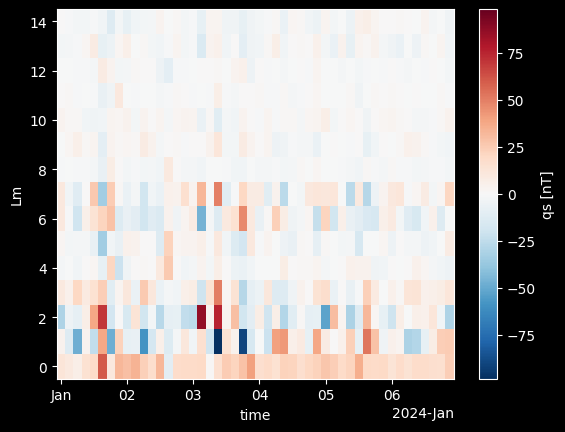

In [13]:
data_out["PAL_MMA_SHA_2E"]["qs"].plot(x="time")

In [15]:
print(data_out["PAL_MMA_SHA_2E"])

<xarray.DataTree 'PAL_MMA_SHA_2E'>
Group: /PAL_MMA_SHA_2E
    Dimensions:       (time: 48, Lm: 15)
    Coordinates:
      * time          (time) datetime64[ns] 384B 2024-01-01 ... 2024-01-06T21:00:00
    Dimensions without coordinates: Lm
    Data variables:
        qs            (time, Lm) float64 6kB 12.66 4.4 -30.42 ... -3.272 -3.918
        gh            (time, Lm) float64 6kB 2.438 4.437 -15.37 ... -7.901 5.394
        R2_e          (time) float64 384B 0.9575 0.9184 0.9263 ... 0.9807 0.9863
        R2_i          (time) float64 384B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
        data_per_bin  (time) float64 384B 444.0 494.0 494.0 ... 498.0 492.0 456.0
        Cm_cond_e     (time) float64 384B 285.0 209.8 233.1 ... 272.6 311.9 288.8
        Cm_cond_i     (time) float64 384B 333.8 293.4 247.6 ... 477.7 428.1 569.4
        MSER_i        (time) float64 384B 1.373 2.488 1.351 ... 0.5984 0.8276 1.491
        MSER_e        (time) float64 384B 4.932 10.01 7.636 ... 1.549 2.222 2.444
    A

In [140]:
 for i, gauss_t in enumerate(data_out["PAL_MMA_SHA_2E"]["qs"]):
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47


## Plotting

In [123]:
from swarmpal_mma.Plotting.map_plot import map_gauss



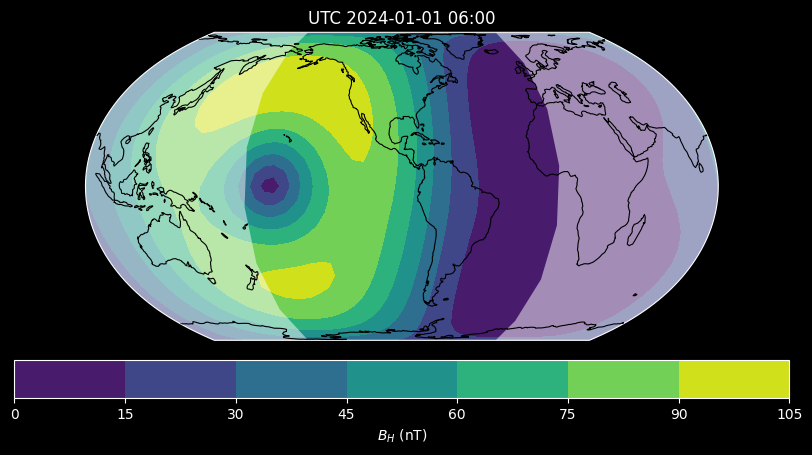

In [124]:
ext = data_out["PAL_MMA_SHA_2E"]["qs"][2]

map_gauss(ext)


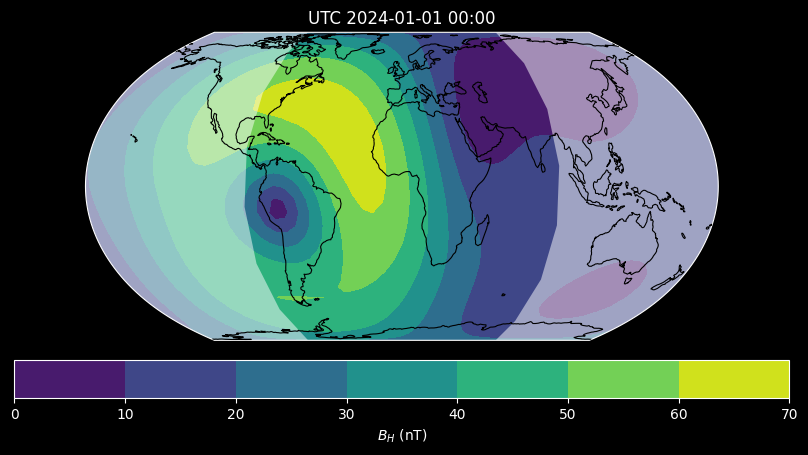

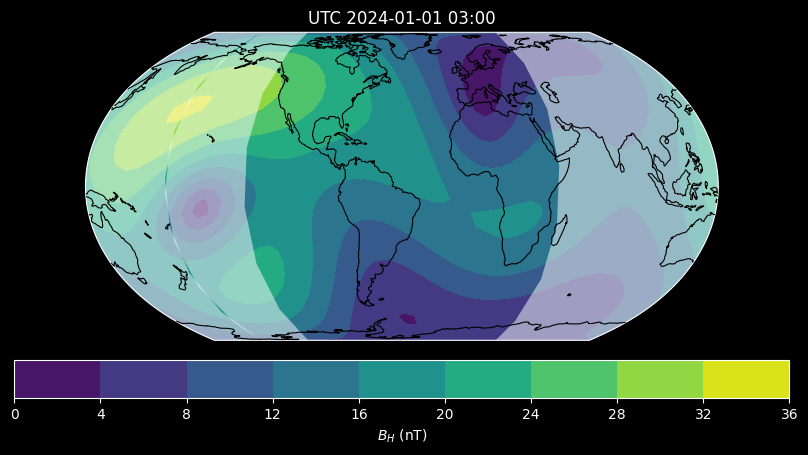

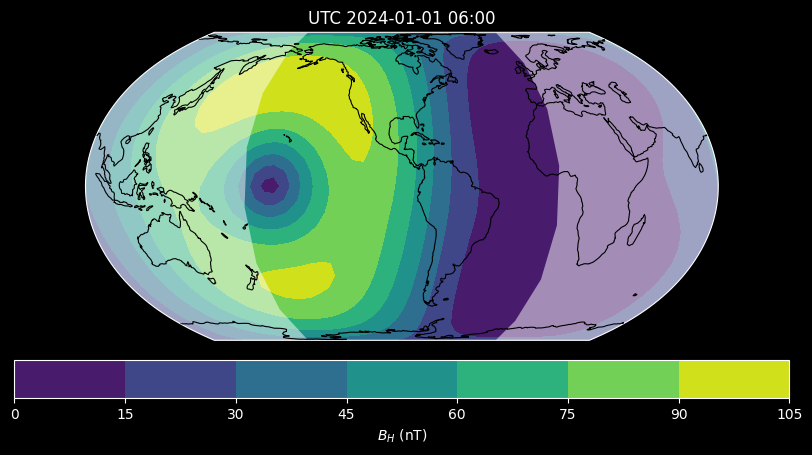

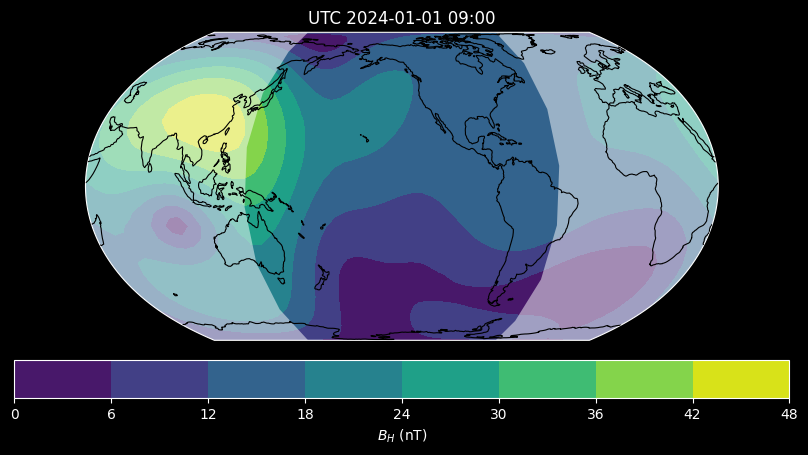

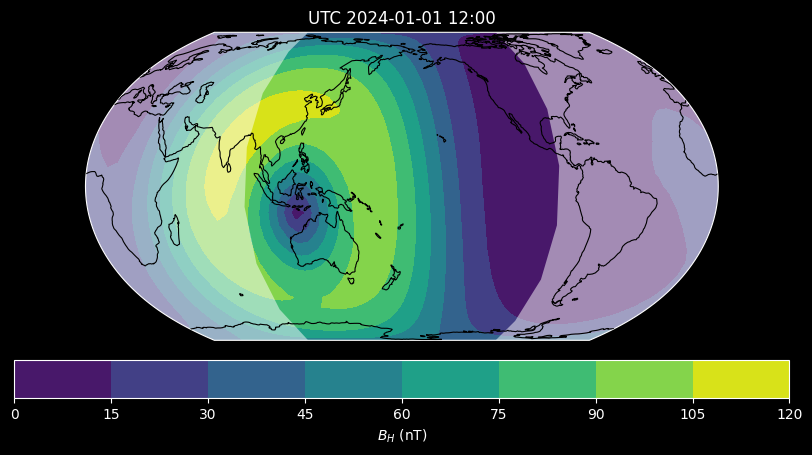

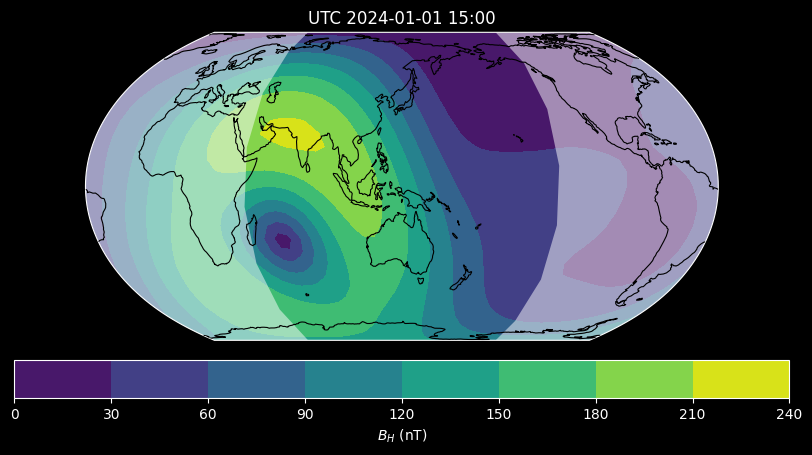

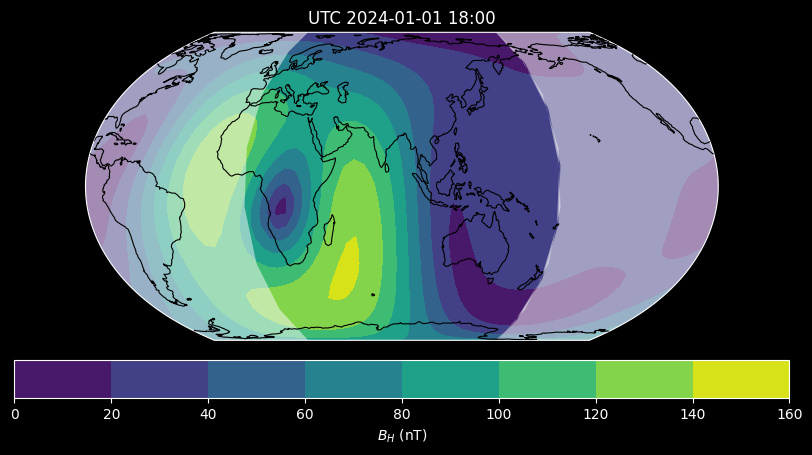

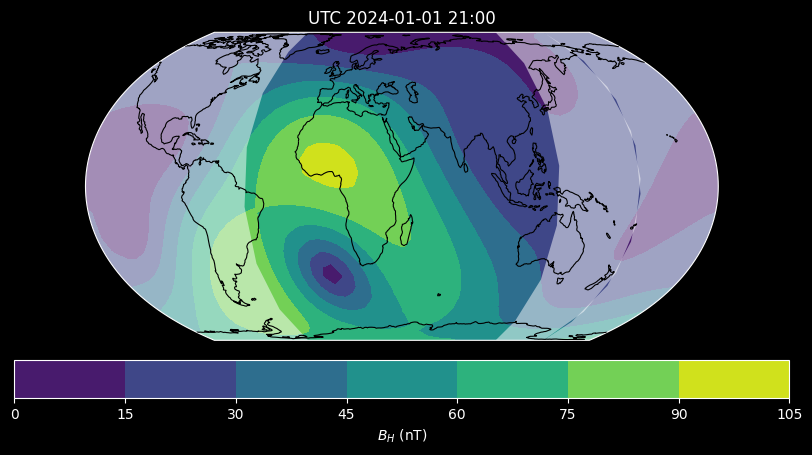

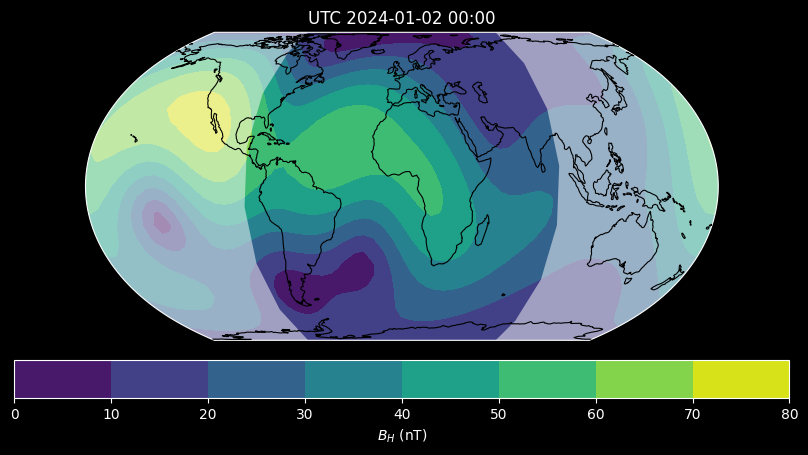

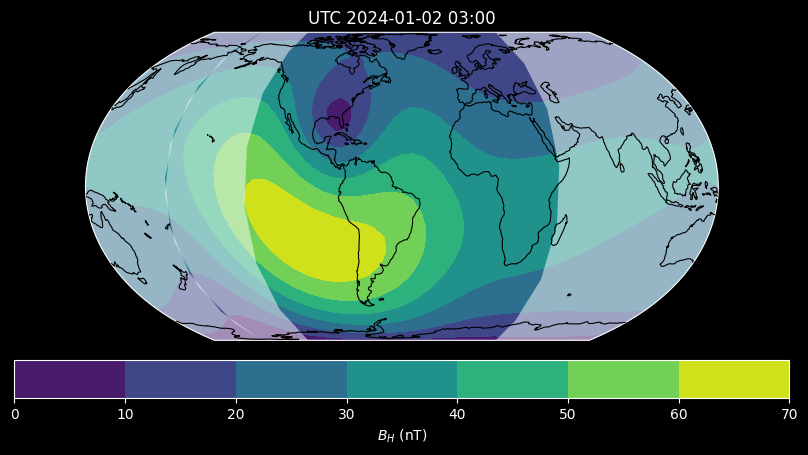

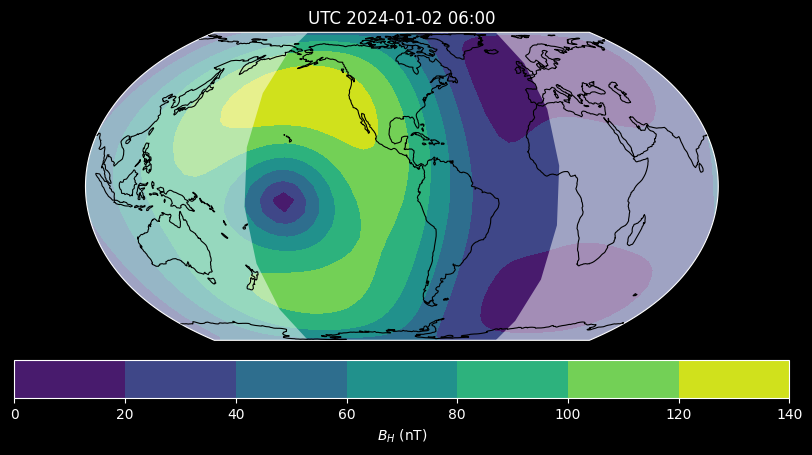

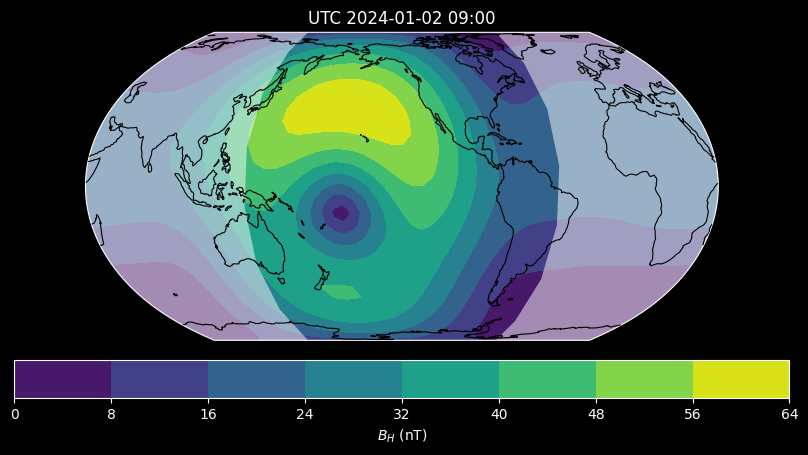

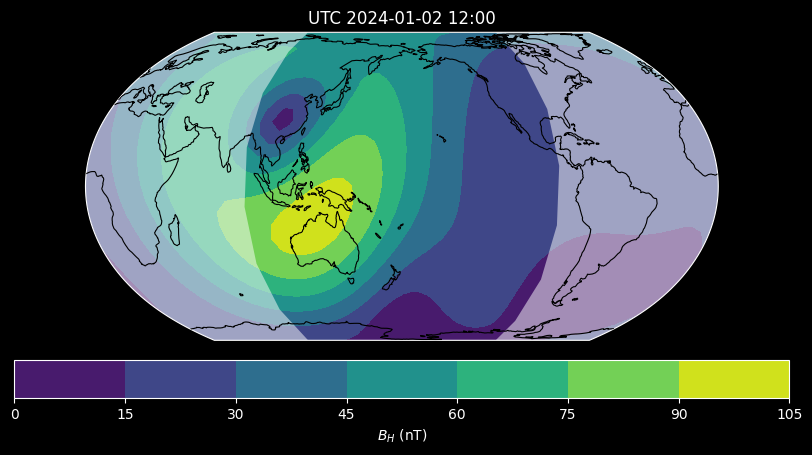

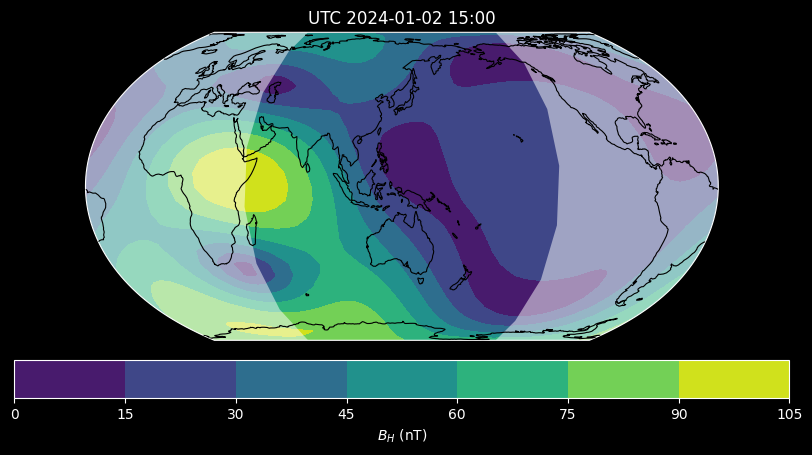

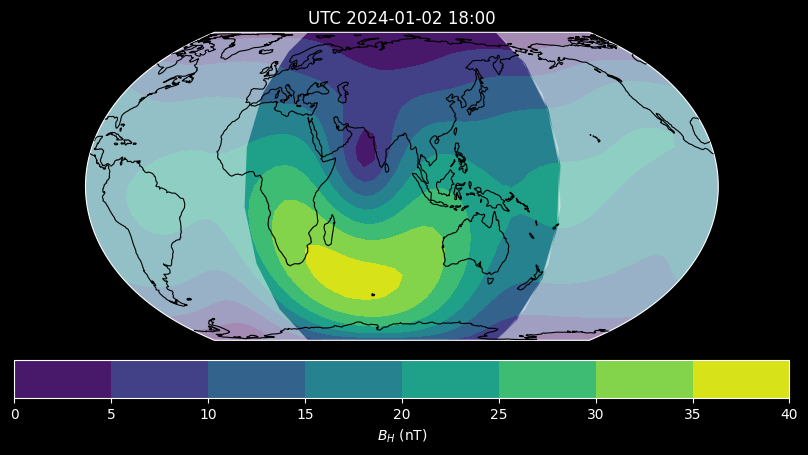

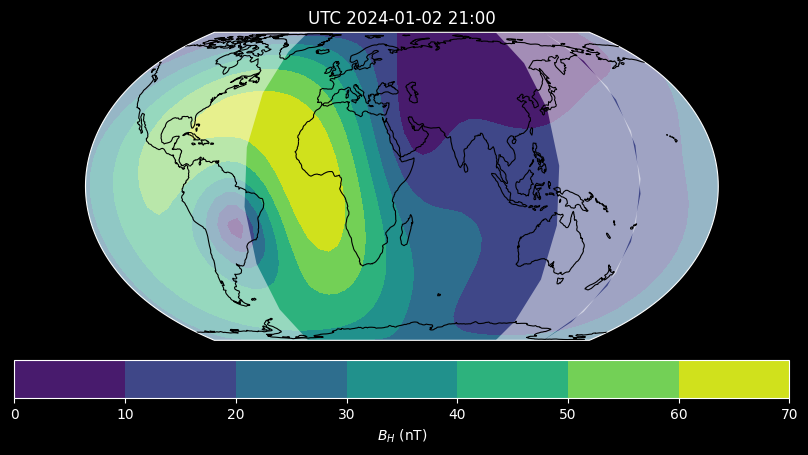

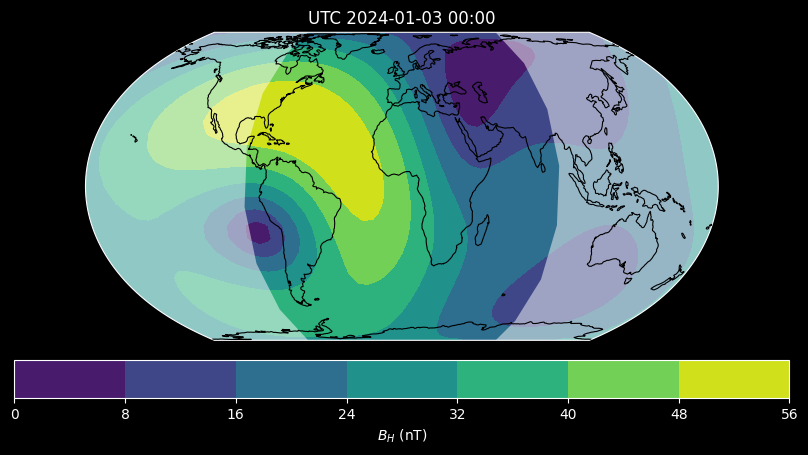

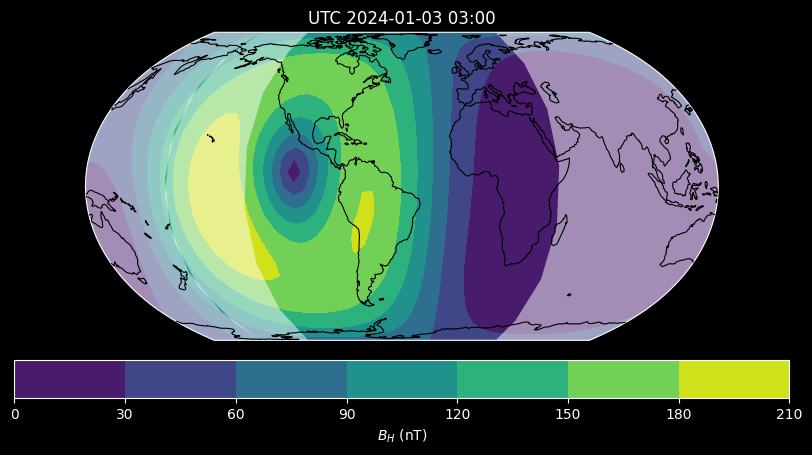

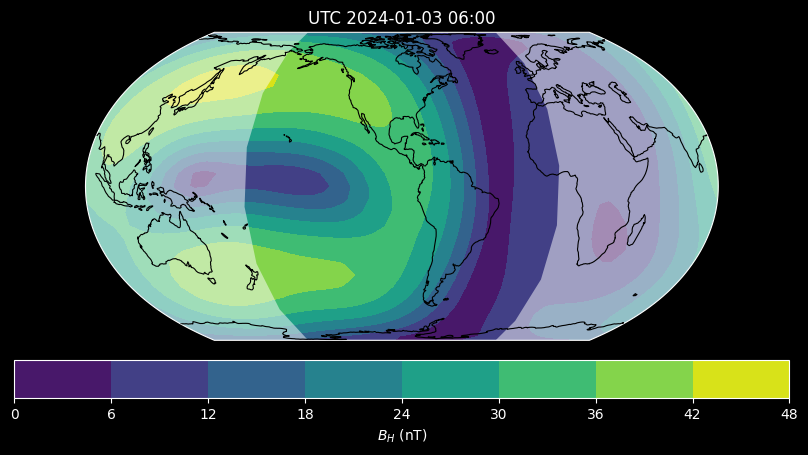

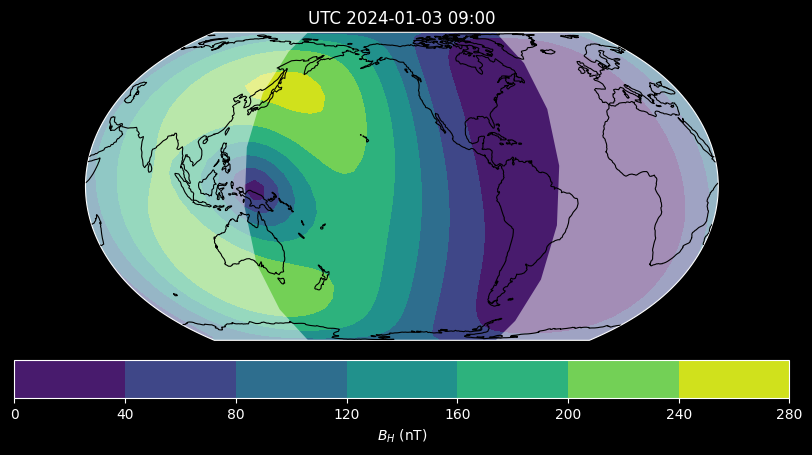

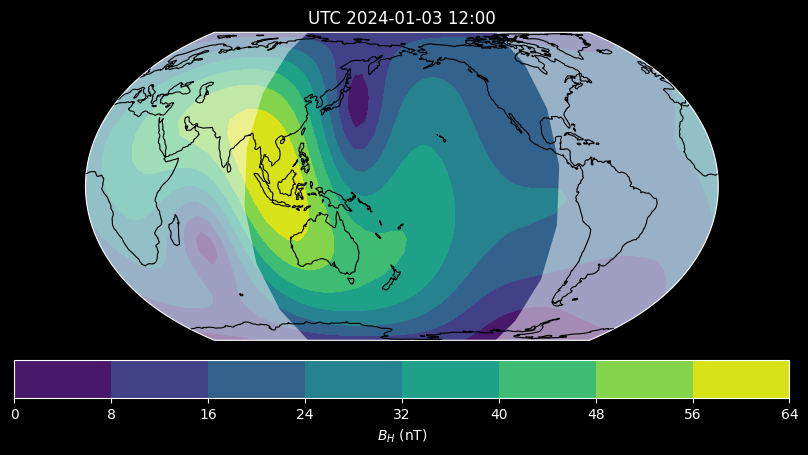

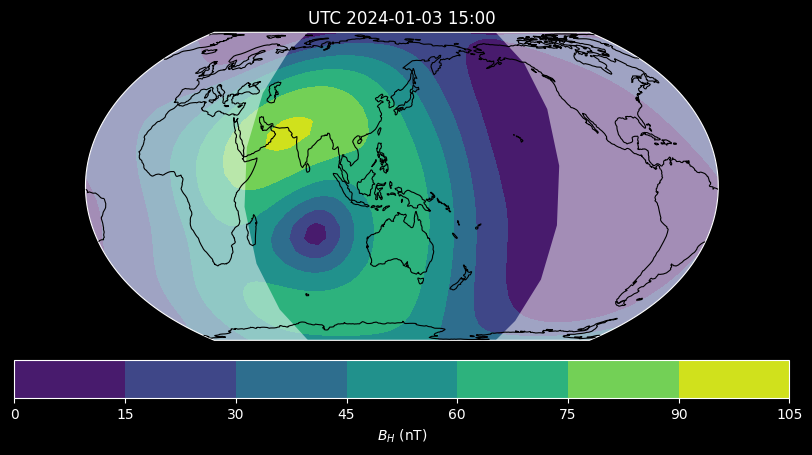

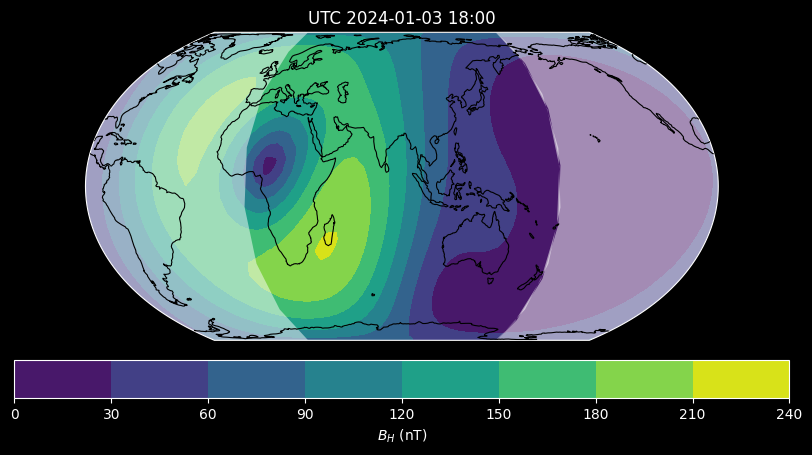

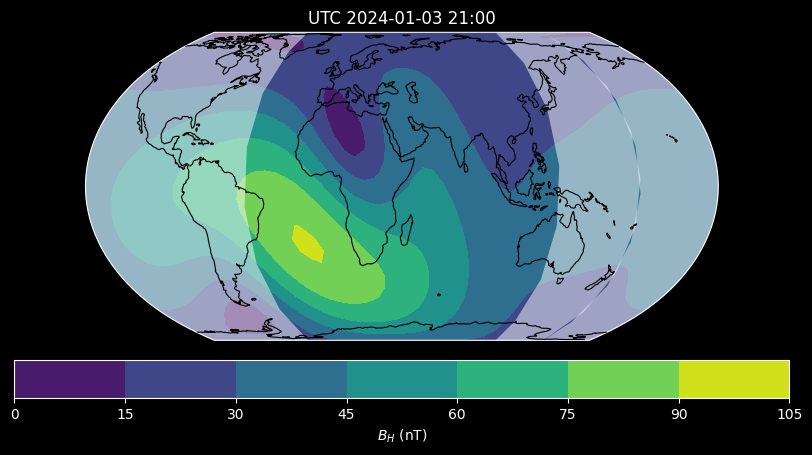

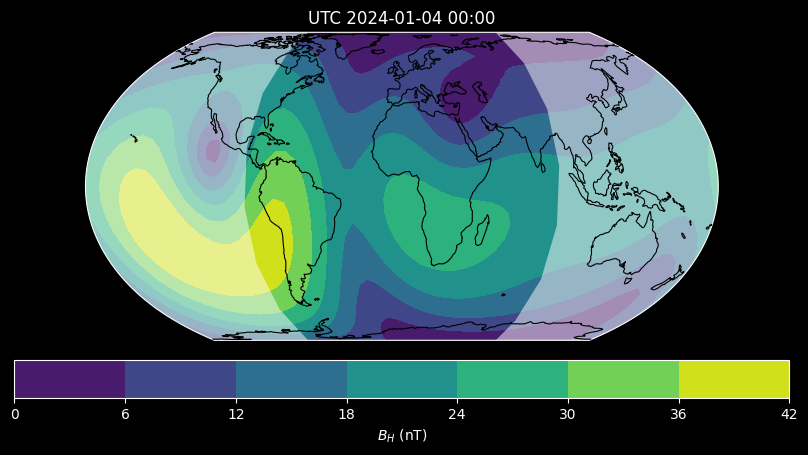

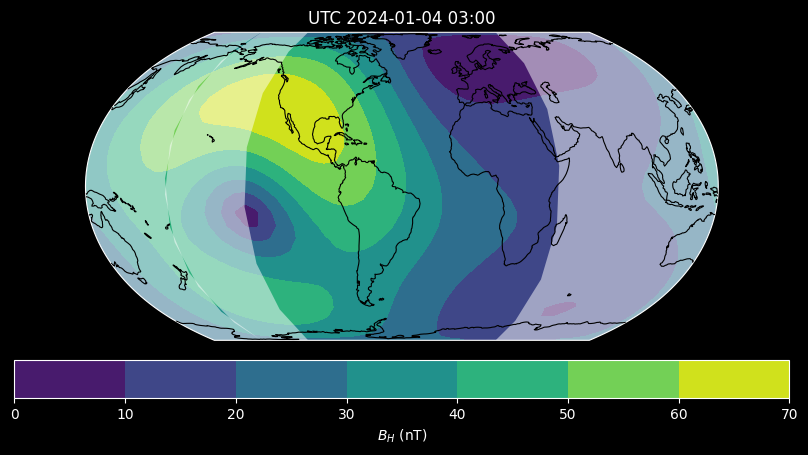

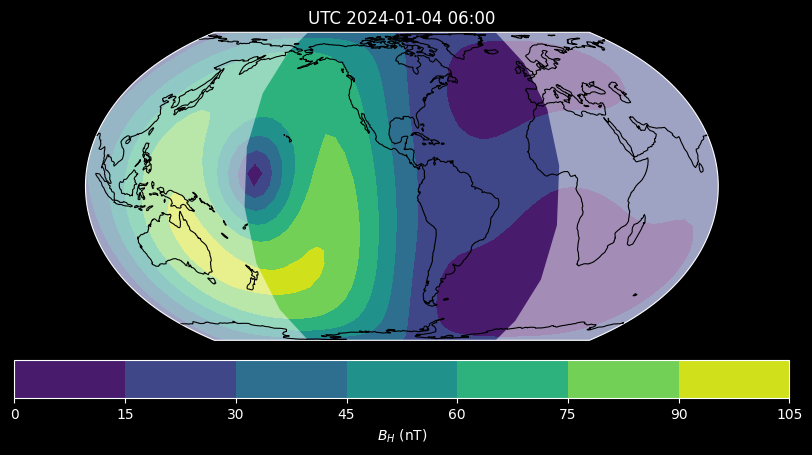

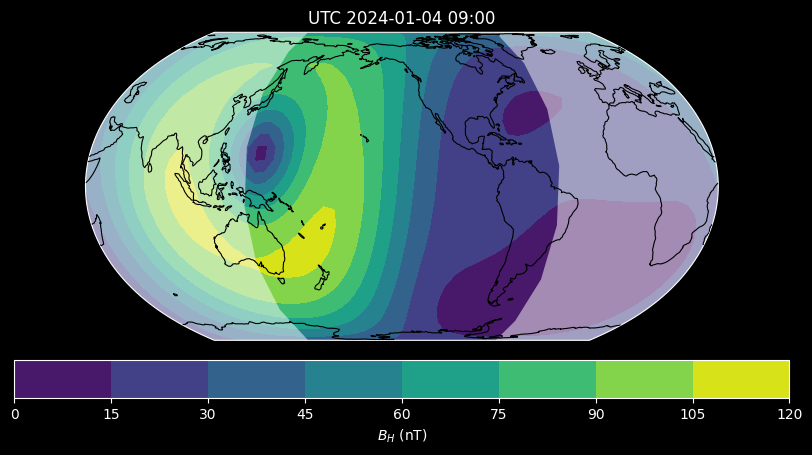

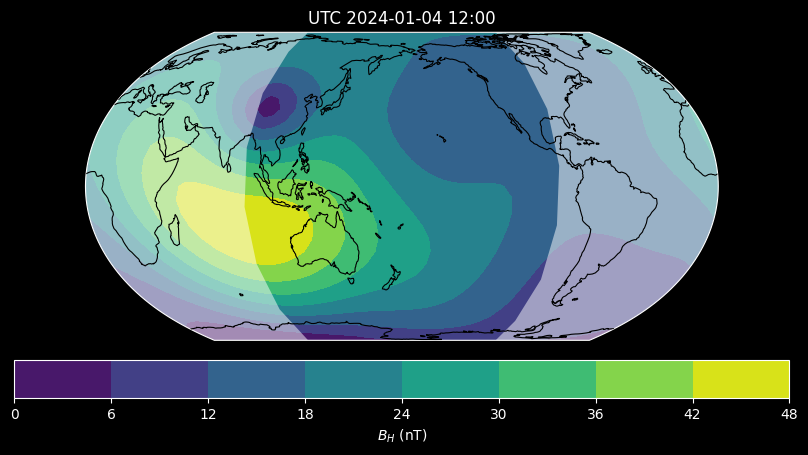

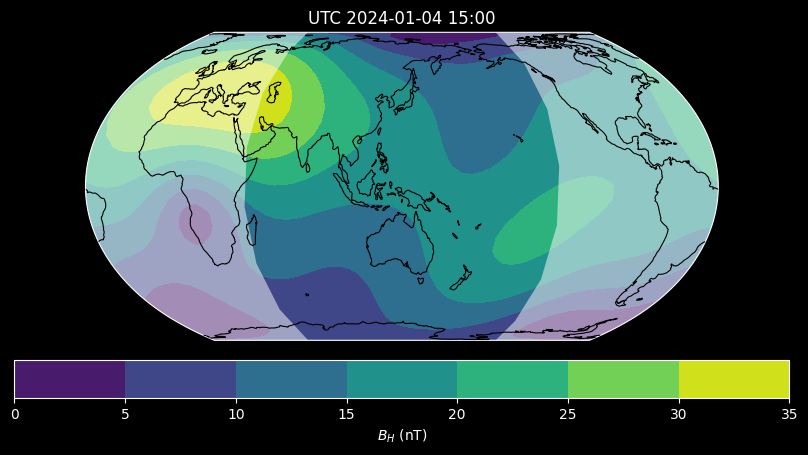

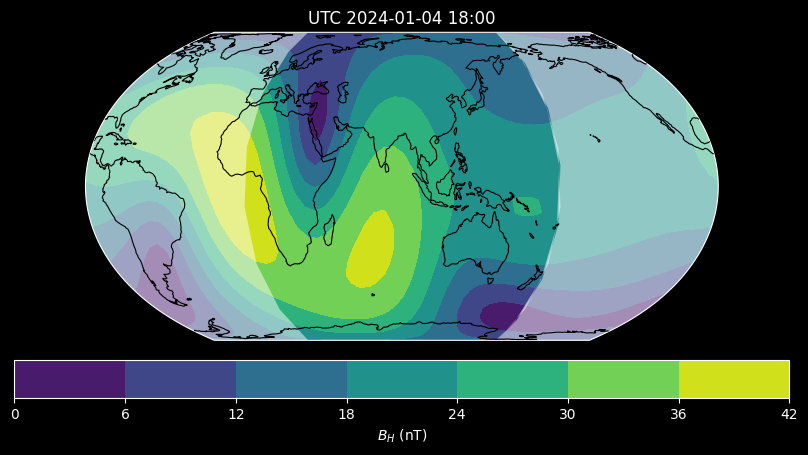

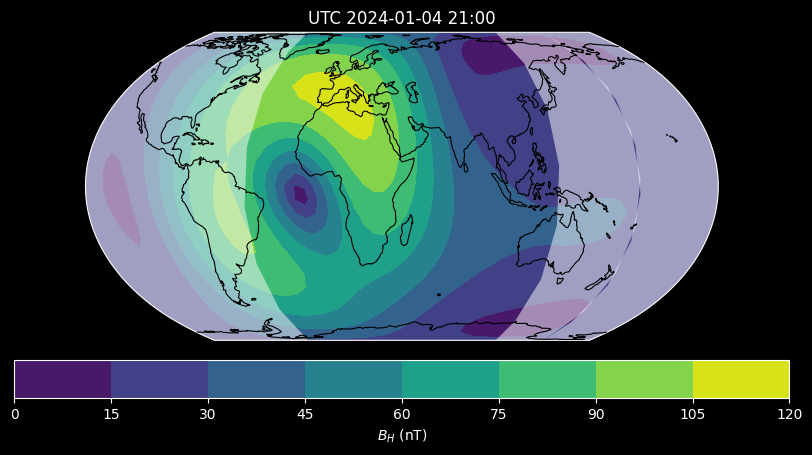

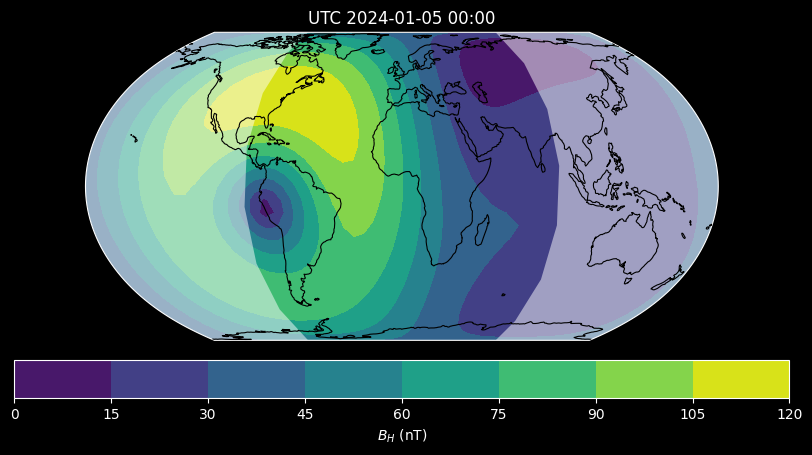

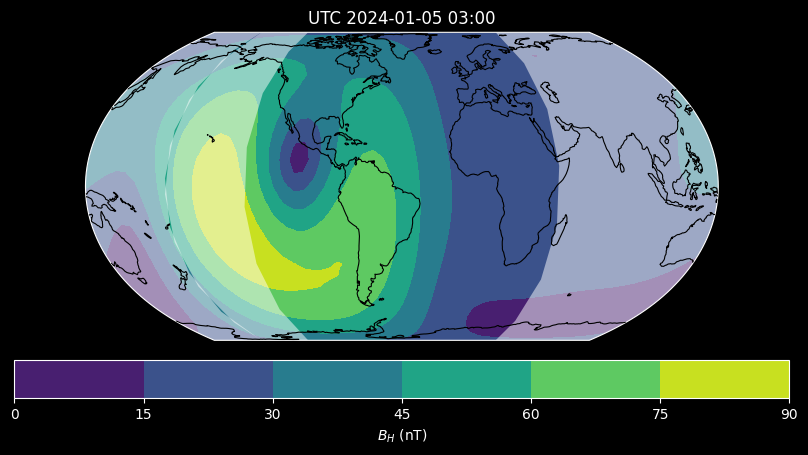

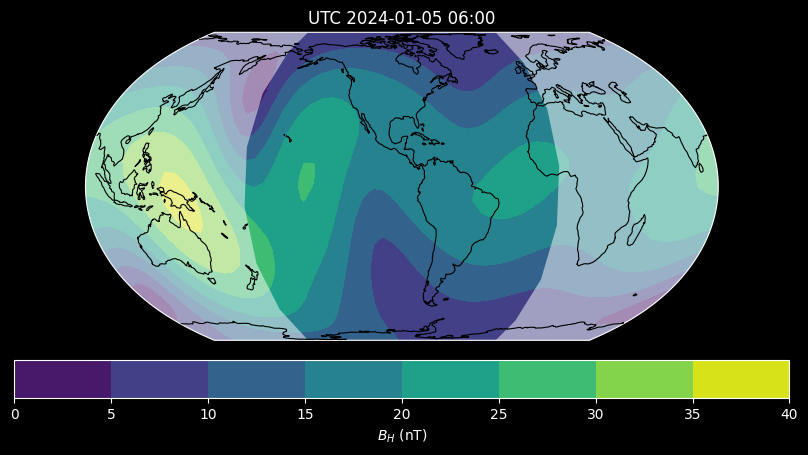

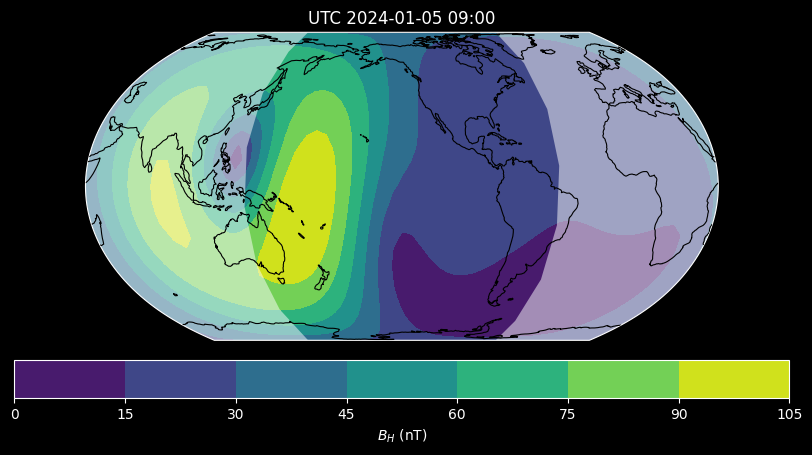

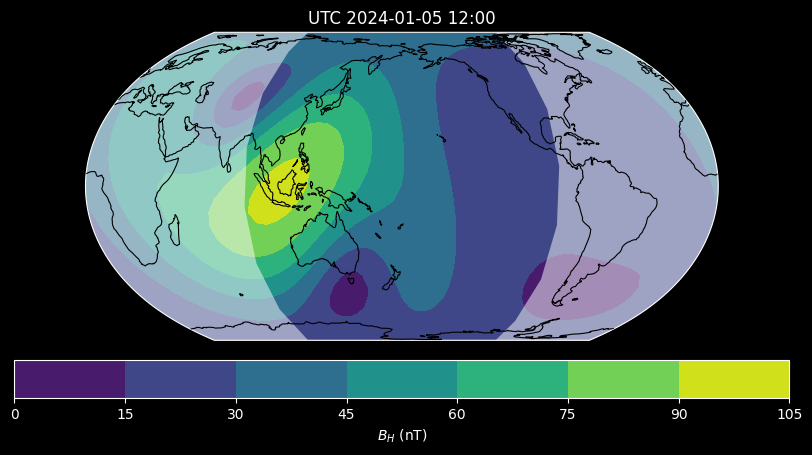

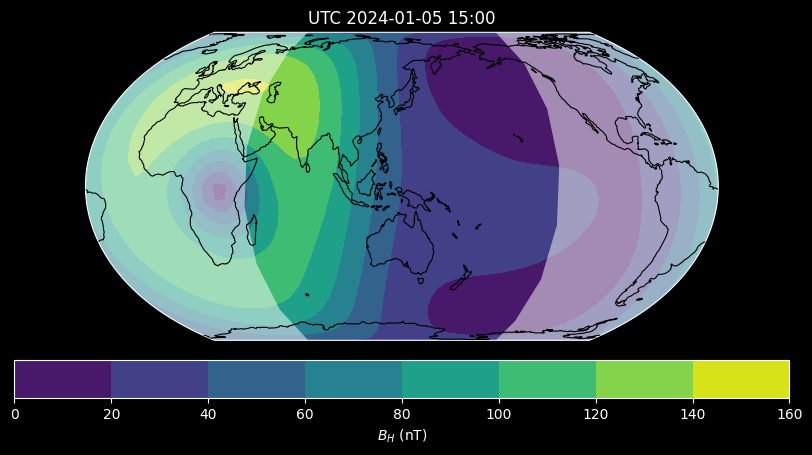

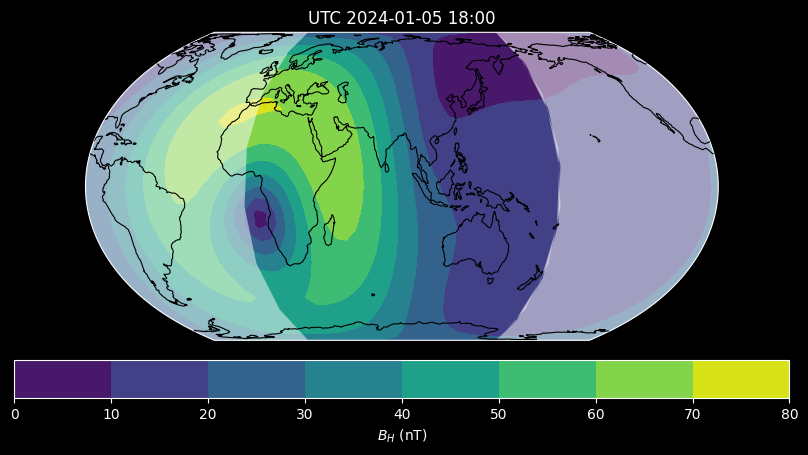

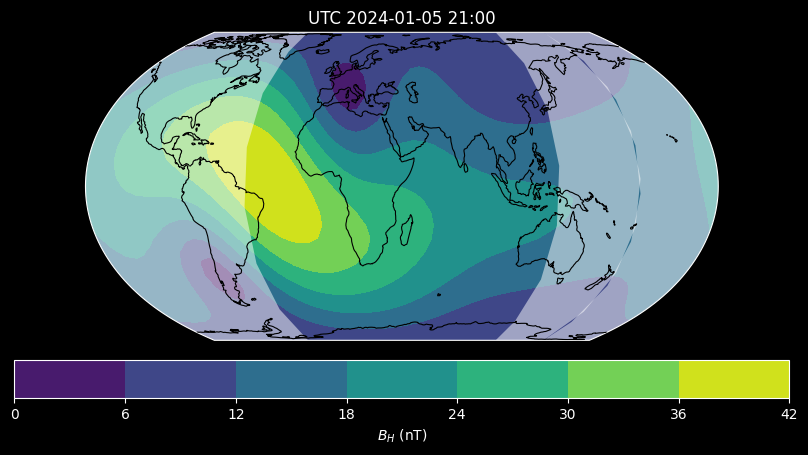

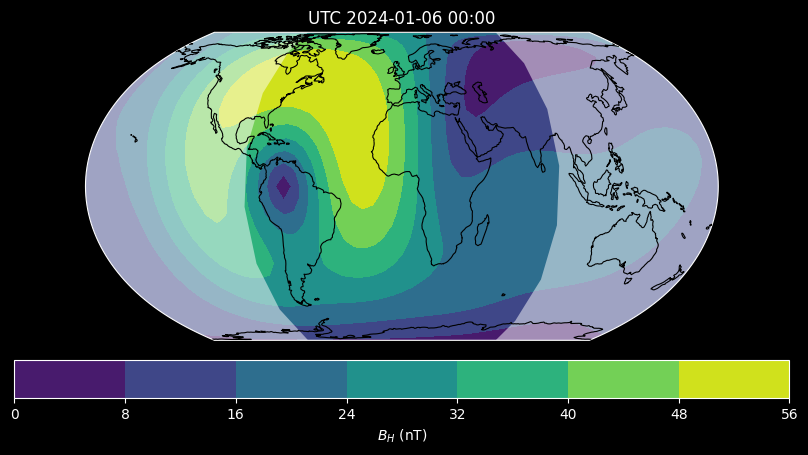

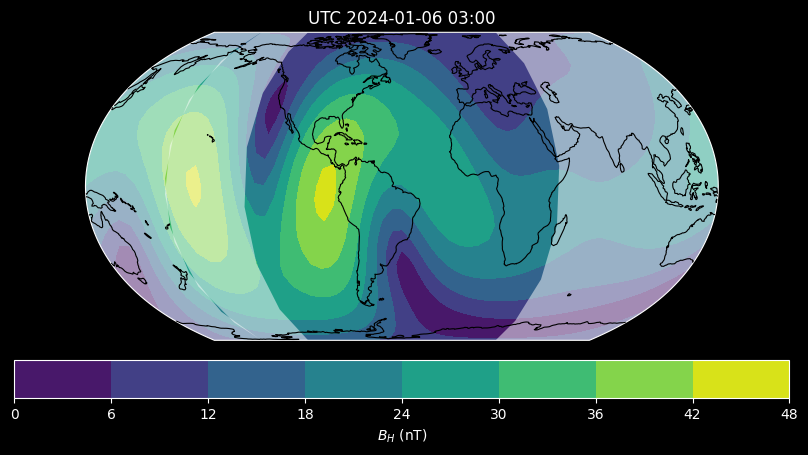

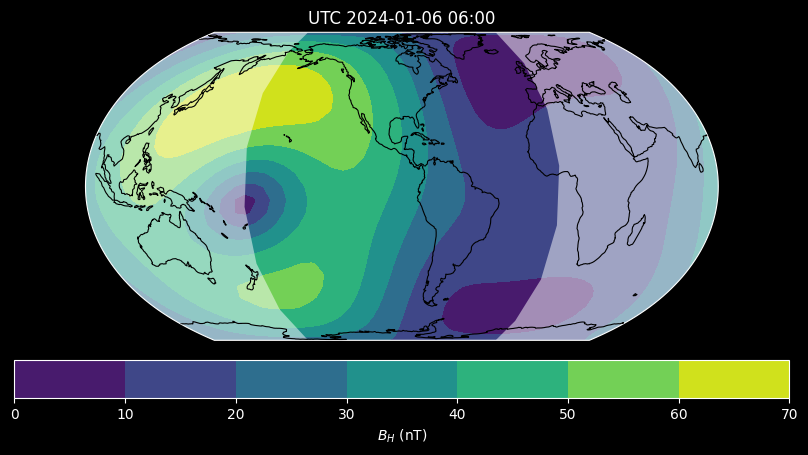

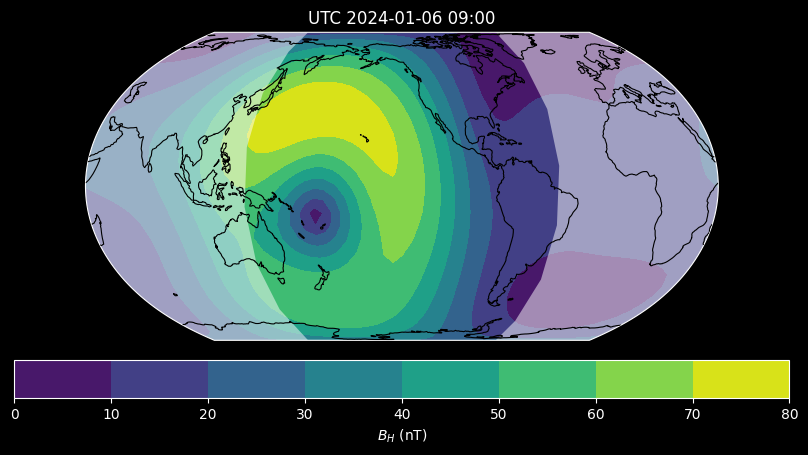

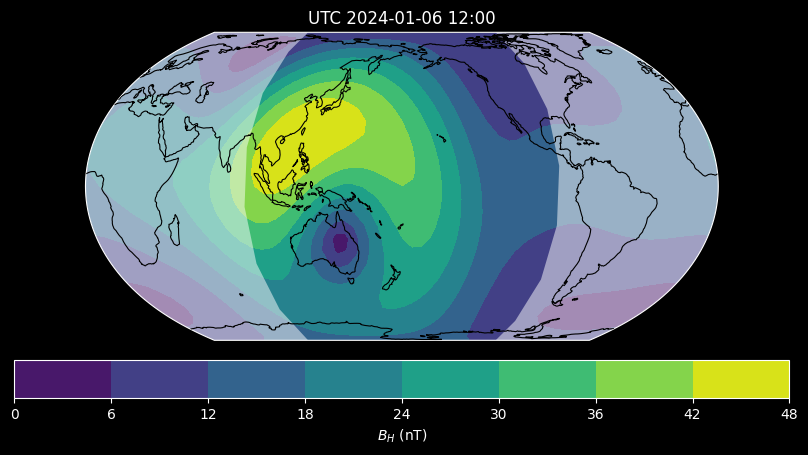

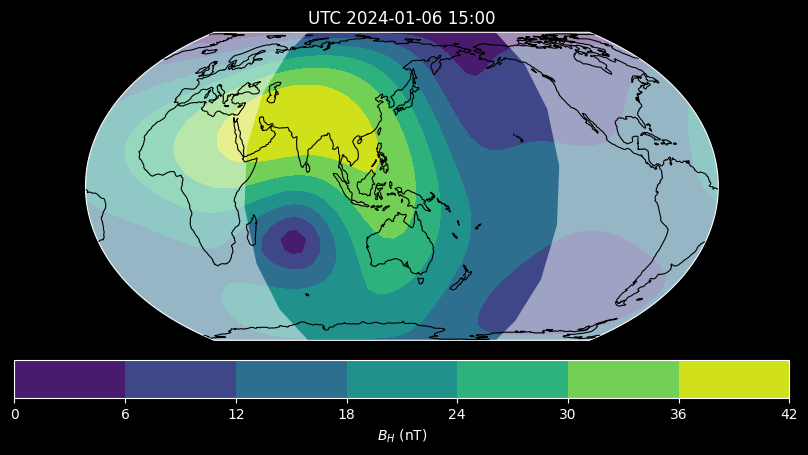

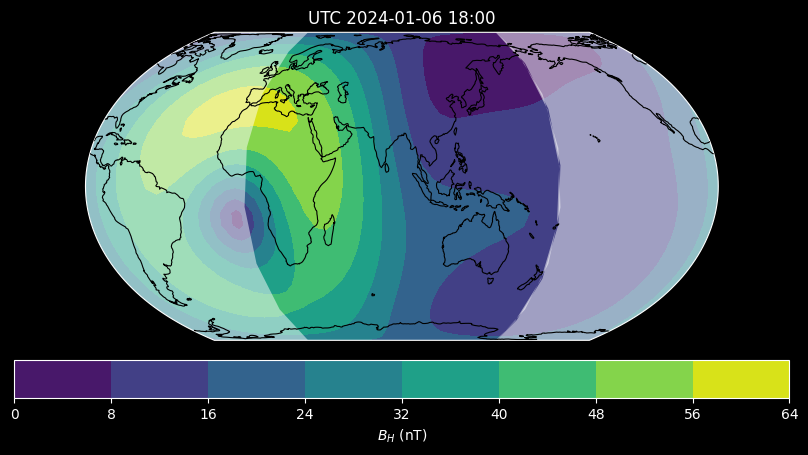

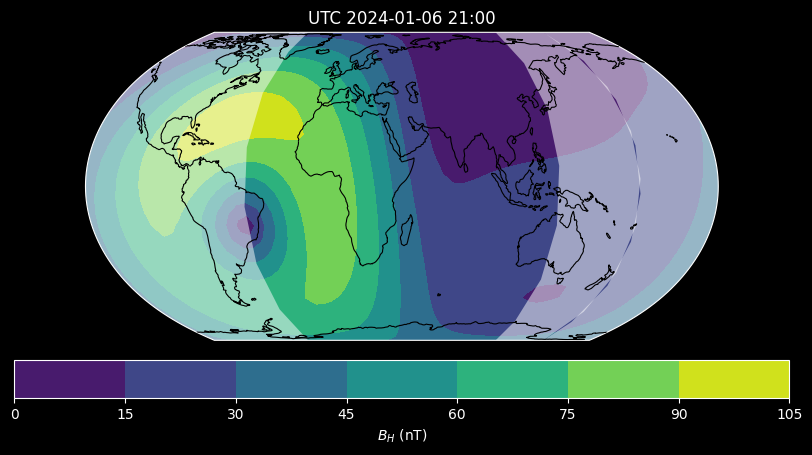

In [125]:
for ext in data_out["PAL_MMA_SHA_2E"]["qs"]:
    map_gauss(ext)

In [116]:
da=ext["time"]

t = pd.to_datetime(ext["time"].item()).to_pydatetime()
t_str = t.strftime("%Y-%m-%d %H:%M")
print(t_str)



2024-01-01 06:00


In [ ]:
map_surface_rtp(data_out["MMA_SHA_2E"]["qs"][0, :])

## Using MSS

Download a file from `MSS-1-A/VFM/SCI-LR` at <https://mss.must.edu.mo/data.html>. Here we will demonstrate with a merged 7-day file. We can load it using swarmpal...

In [ ]:
file = Path("MSS1A_TEST_VFM_L2_MAG_SCI-LR_20240101T000000_20240106T235959.cdf")
assert file.exists()
data_mss_in = create_paldata(
    **{"MSS1A_TEST_VFM_L2_MAG_SCI-LR": PalDataItem.from_file(file)}
)
print(data_mss_in)

Note that since we didn't fetch the data from VirES, there are no geomagnetic field model predictions, which are required to use the MMA toolbox.

As an experimental SwarmPAL feature, we can evaluate the CHAOS field locally (rather than using the VirES API):

(NB we will just use the CHAOS-Core field in this case)

In [ ]:
from swarmpal.experimental import LocalForwardMagneticModel


process_local_model = LocalForwardMagneticModel()
process_local_model.set_config(
    dataset="MSS1A_TEST_VFM_L2_MAG_SCI-LR",
    model_descriptor="CHAOS-Core",
)
data_mss_in = process_local_model(data_mss_in)
print(data_mss_in)

In [ ]:
# NB for now we must instruct the MMA process to use the specific variable names
mma_process = MMA_SHA_2E()
mma_process.set_config(
    measurement_varname="B_NEC",
    model_varname="B_NEC_CHAOS-Core",
)
data_mss_out = mma_process(data_mss_in)

In [ ]:
map_surface_rtp(data_mss_out["MMA_SHA_2E"]["qs"][0, :])

## Using a combination of data sources

In [ ]:
# Fetch remote data, and load local data
data = create_paldata(
    **{
        "Swarm-A": PalDataItem.from_vires(
            collection="SW_OPER_MAGA_LR_1B",
            measurements=["B_NEC"],
            models=["CHAOS-Core"],
            sampling_step="PT25S",
            start_time="2024-01-01",
            end_time="2024-01-07",
            server_url="https://vires.services/ows",
            options=dict(asynchronous=False, show_progress=True),
        ),
        "Swarm-B": PalDataItem.from_vires(
            collection="SW_OPER_MAGB_LR_1B",
            measurements=["B_NEC"],
            models=["CHAOS-Core"],
            sampling_step="PT25S",
            start_time="2024-01-01",
            end_time="2024-01-07",
            server_url="https://vires.services/ows",
            options=dict(asynchronous=False, show_progress=True),
        ),
        "MSS-1-A": PalDataItem.from_file(
            Path("MSS1A_TEST_VFM_L2_MAG_SCI-LR_20240101T000000_20240106T235959.cdf")
        )
    }
)
# Downsample the MSS-1-A data to match the Swarm data
data["MSS-1-A"] = data["MSS-1-A"].sel(Timestamp=data["MSS-1-A"].ds["Timestamp"][::25])
# Apply the local forward model to the MSS-1-A data
print("Computing local forward model...")
process_local_model = LocalForwardMagneticModel()
process_local_model.set_config(
    dataset="MSS-1-A",
    model_descriptor="CHAOS-Core",
)
process_local_model(data)
print(data)

In [ ]:
mma_process = MMA_SHA_2E()
mma_process.set_config(
    measurement_varname="B_NEC",
    model_varname="B_NEC_CHAOS-Core",
)
mma_process(data);
print(data)

In [ ]:
map_surface_rtp(data["MMA_SHA_2E"]["qs"][0, :])